# Create dataframes

In this notebook, dataframes are created for each classifier.

After the online simulation on all patients, the classifier's performance scores (epoch-wise and trial-wise accuracy) are stored in a pickle file per patient. This notebook reads from those pickle files and stores all performance scores in a .csv file per classifier.

The dataframes are read in `comparing_classifiers.ipnyb`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from results_functions import grand_average, plot_all_patients, get_scores_all_patients
from db import patients_db


### Static

In [3]:
directory = "storage/pickle_files/20-06/static/"
pickle_name = "performances_static_v3"
strategy = "static"
clf = "btlda"
score = "ews"

ews_all_static = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
ews_avg_static = grand_average(ews_all_static) 
score = "tws"
tws_all_static = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
tws_avg_static = grand_average(tws_all_static) 

static_scores_ews = []
for p in ews_all_static.keys():
    static_scores_ews.append(ews_all_static.get(p)) 

static_scores_tws = []
for p in tws_all_static.keys():
    static_scores_tws.append(tws_all_static.get(p))     

### aphasia sLDA

In [5]:
directory = "storage/pickle_files/20-06/aphasia_slda/"
pickle_name = "aphasia_slda"
strategy = "adaptive_slda"
clf = "slda"
score = "ews"

ews_all_aphasia_slda = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
ews_avg_aphasia_slda = grand_average(ews_all_aphasia_slda) 
score = "tws"
tws_all_aphasia_slda = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
tws_avg_aphasia_slda = grand_average(tws_all_aphasia_slda) 

aphasia_slda_scores_ews = []
for p in ews_all_aphasia_slda.keys():
    aphasia_slda_scores_ews.append(ews_all_aphasia_slda.get(p)) 

aphasia_slda_scores_tws = []
for p in tws_all_aphasia_slda.keys():
    aphasia_slda_scores_tws.append(tws_all_aphasia_slda.get(p))     

### function to store a dataframe

In [ ]:
import pandas as pd
data = []
for patient, patient_scores in enumerate(aphasia_slda_scores_ews, start=1):
    for session_id, score in enumerate(patient_scores, start=3):
        # p8 started one session later than the rest
        if patient==8:
            extra = 1
        else:
            extra = 0    

        manual_ews = aphasia_slda_scores_ews[patient-1][session_id-3]  # this gives the same output as "score"
        manual_tws = aphasia_slda_scores_tws[patient-1][session_id-3]    

        data.append(({'patient': patient, 'session': session_id+extra, 'ews': manual_ews, 'tws':manual_tws}))

df = pd.DataFrame(data)
print(df)
df.to_csv('aphasia_sldadata.csv', index=False)

In [ ]:
# Transfer Fixed BT-LDA
# v2 means that the new features 0.1-0.8s in 50 ms steps are used (the previous version had range 0.1-0.8s)
directory = "storage/pickle_files/13-06/transfer_v2/"
pickle_name = "transfer_v2"
strategy = "transfer"
clf = "btlda"
score = "ews"

ews_all_transfer = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, version_suffix="_v2", directory=directory)
ews_avg_transfer = grand_average(ews_all_transfer) 

score = "tws"
tws_all_transfer = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, version_suffix="_v2", directory=directory)
tws_avg_transfer = grand_average(tws_all_transfer) 


### Window

In [ ]:
# Experimental (not used in thesis): Window BT-LDA with window size M = # epochs of previous session
directory = "storage/pickle_files/14-06/window_v4/"
pickle_name = "window_v4"
strategy = "window_v4"
clf = "btlda"
score = "ews"

ews_all_window_v4 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
ews_avg_window_v4 = grand_average(ews_all_window_v4) 
score = "tws"
tws_all_window_v4 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
tws_avg_window_v4 = grand_average(tws_all_window_v4) 

w4_scores_ews = []
for p in ews_all_window_v4.keys():
    w4_scores_ews.append(ews_all_window_v4.get(p)) 

w4_scores_tws = []
for p in tws_all_window_v4.keys():
    w4_scores_tws.append(tws_all_window_v4.get(p)) 


In [ ]:
# Adaptive Window BT-LDA: Fixed window of M = 3600 data points / epochs
directory = "storage/pickle_files/14-06/window_v5/"
pickle_name = "window_v5"
strategy = "window_v5"
clf = "btlda"
score = "ews"

ews_all_window_v5 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
ews_avg_window_v5 = grand_average(ews_all_window_v5) 
score = "tws"
tws_all_window_v5 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
tws_avg_window_v5 = grand_average(tws_all_window_v5) 

w5_scores_ews = []
for p in ews_all_window_v5.keys():
    w5_scores_ews.append(ews_all_window_v5.get(p)) 

    
w5_scores_tws = []
for p in tws_all_window_v5.keys():
    w5_scores_tws.append(tws_all_window_v5.get(p)) 



### Transfer

In [133]:
pickle_name = "transfer_v2"
strategy = "transfer"
clf = "btlda"
score = "ews"

ews_all_transfer = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, version_suffix="_v2")
ews_avg_transfer = grand_average(ews_all_transfer) 

score = "tws"
tws_all_transfer = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, version_suffix="_v2")
tws_avg_transfer = grand_average(tws_all_transfer) 


### Adaptive CC BT-LDA

In [9]:
# optimized UC-pair from odds (used for evens)

directory = "storage/pickle_files/17-06/"
pickle_name = "cc_v2"
strategy = "cc_v2"
clf = "btlda"
score = "ews"

ews_all_cc_v2 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
ews_avg_cc_v2 = grand_average(ews_all_cc_v2) 
score = "tws"
tws_all_cc_v2 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
tws_avg_cc_v2 = grand_average(tws_all_cc_v2) 

cc2_ews_scores = []
for p in ews_all_cc_v2.keys():
    cc2_ews_scores.append(ews_all_cc_v2.get(p)) 

cc2_tws_scores = []
for p in tws_all_cc_v2.keys():
    cc2_tws_scores.append(tws_all_cc_v2.get(p))  

# Get optimized even UC-pair (used for odds)    

directory = "storage/pickle_files/20-06/"
pickle_name = "cc_uc_even"
strategy = "cc_v2"
clf = "btlda"
score = "ews"

ews_all_cc_v3 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False, directory=directory)
ews_avg_cc_v3 = grand_average(ews_all_cc_v3) 

score = "tws"
tws_all_cc_v3 = get_scores_all_patients(pickle_name, strategy=strategy, classifier=clf, score=score, verbose=False,directory=directory)
tws_avg_cc_v3 = grand_average(tws_all_cc_v3) 

cc3_ews_scores = []
for p in ews_all_cc_v3.keys():
    cc3_ews_scores.append(ews_all_cc_v3.get(p)) 

cc3_tws_scores = []
for p in tws_all_cc_v3.keys():
    cc3_tws_scores.append(tws_all_cc_v3.get(p))

def store_cc_data(cc2_ews_scores, cc2_tws_scores, cc3_ews_scores, cc3_tws_scores):
    data = []
    for patient, patient_scores in enumerate(cc2_ews_scores, start=1):
        if patient%2 == 0:
            # for even patients, get score cc v2
            for session_id, score in enumerate(patient_scores, start=3):
                # if patient==8 and session_id==3: # skip session 18 for  p8 bc that has value 0 (p8 started one session later than the rest)
                #     continue
                if patient==8:
                    extra = 1
                else:
                    extra = 0    

                manual_ews = cc2_ews_scores[patient-1][session_id-3]  # this gives the same output as "score"
                manual_tws = cc2_tws_scores[patient-1][session_id-3]    
        
                data.append(({'patient': patient, 'session': session_id+extra, 'ews': manual_ews, 'tws':manual_tws}))

        else:
            # for odd patients, get score cc v3
            for session_id, score in enumerate(patient_scores, start=3):
                if patient==8:
                    extra = 1
                else:
                    extra = 0    

                manual_ews = cc3_ews_scores[patient-1][session_id-3]  # this gives the same output as "score"
                manual_tws = cc3_tws_scores[patient-1][session_id-3]    
        
                data.append(({'patient': patient, 'session': session_id+extra, 'ews': manual_ews, 'tws':manual_tws}))    
    df = pd.DataFrame(data)
    print(df)
    df.to_csv('ccdata.csv', index=False)    

In [ ]:
import pandas as pd
def _create_dataframe(dict):
    df_long = pd.DataFrame(dict)
    return df_long

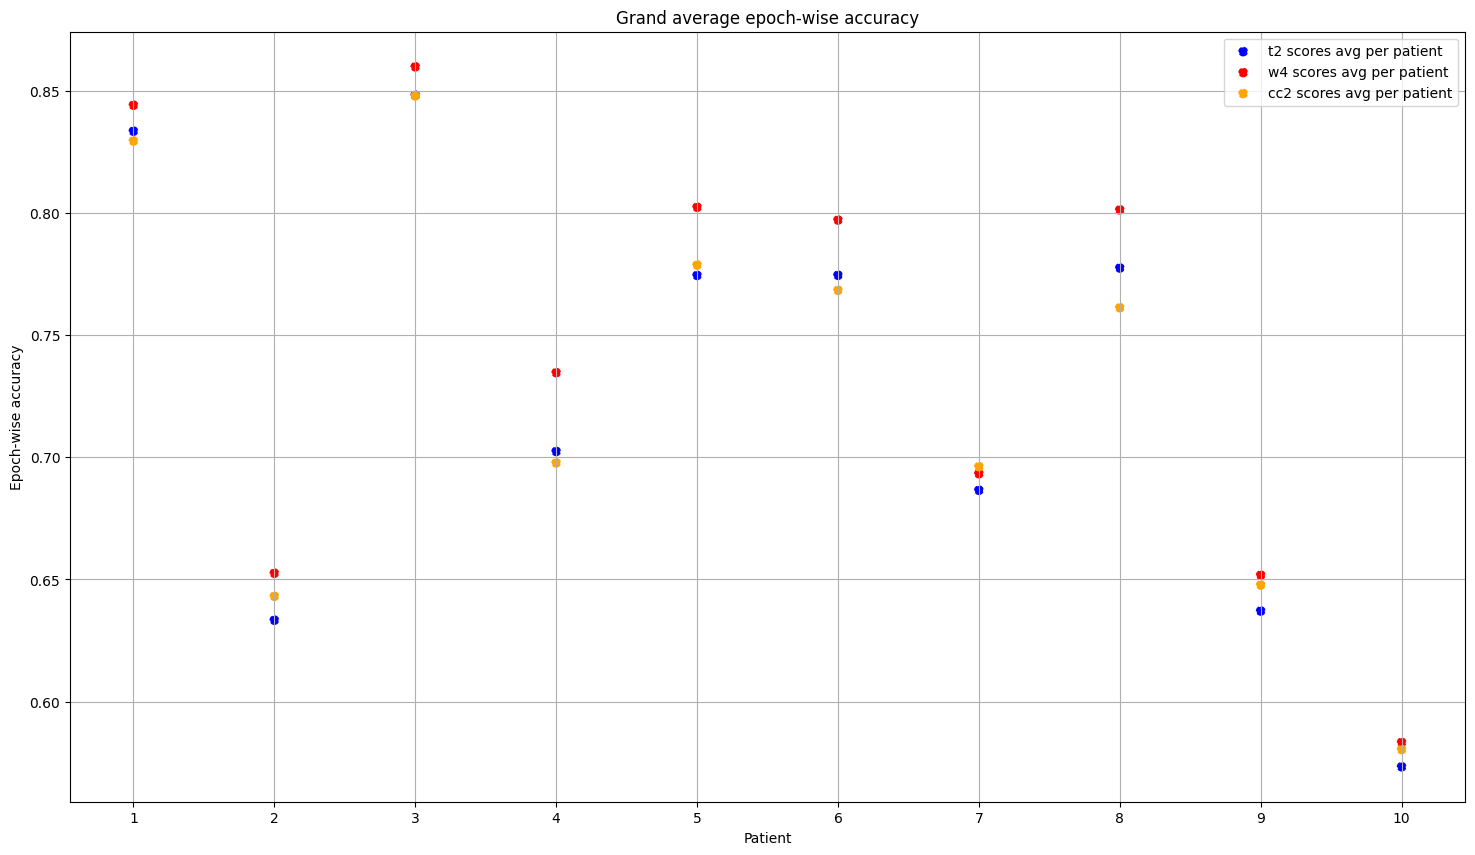

In [ ]:

plt.figure(figsize=(18,10))
#plt.plot(ews_avg_static, label="Static Fixed", linestyle='dashed')
# plt.plot([np.mean(l) for l in t1_scores],label="t1 scores", color="green")
# plt.plot([np.mean(l) for l in w3_scores],label="w3 scores", color="pink")

plt.scatter(y=[np.mean(l) for l in t2_ews_scores], x=np.arange(0,10),label="t2 scores avg per patient", color="blue", linestyle="dashed")
plt.scatter(y=[np.mean(l) for l in w4_ews_scores],x=np.arange(0,10), label="w4 scores avg per patient", color="red", linestyle="dashed")
plt.scatter(y=[np.mean(l) for l in cc2_ews_scores],x=np.arange(0,10), label="cc2 scores avg per patient", color="orange", linestyle="dashed")

# plt.plot(ews_avg_transfer, label="Transfer Fixed-V1 (s)", color="tab:blue")
# plt.plot(ews_avg_window_v3, label="Window v3 (s)", color="red")

# plt.plot(ews_avg_transfer_v2, label="Transfer Fixed V2 (l) avg per session", color="tab:blue",linestyle='dashed')
# plt.plot(ews_avg_window_v4, label="Window v4 (l) avg per session", color="red",linestyle='dashed')
plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Patient')
#plt.ylim(0.1,1)
# plt.xticks(np.arange(0,25), np.arange(3,28))  
plt.xticks(np.arange(0,10), np.arange(1,11))  
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

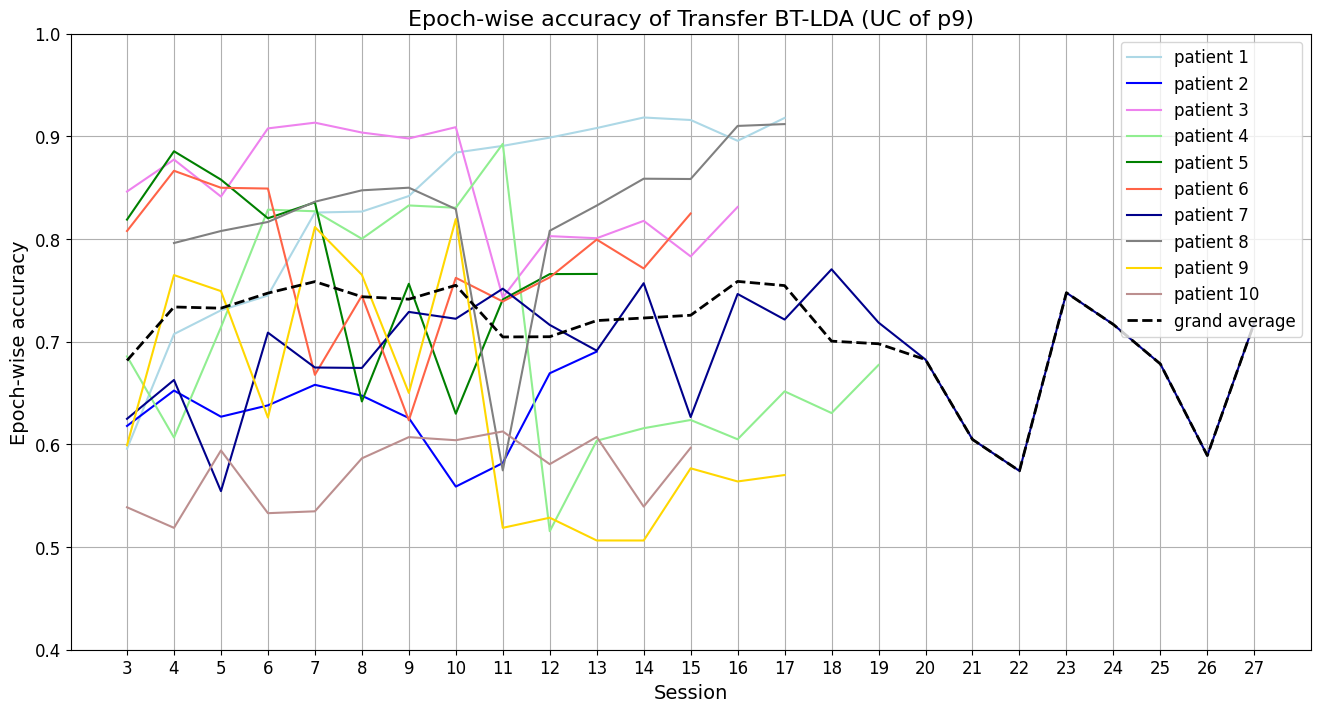

In [143]:
acc_all_patients = ews_all_transfer
grand_avg = ews_avg_transfer
title="Epoch-wise accuracy of Transfer BT-LDA (UC of p9)"
ylabel="Epoch-wise accuracy"

ylim=(0.4,1)
colors=['lightblue','lightblue','blue','violet','lightgreen','green','tomato', 'darkblue', 'grey', 'gold', 'rosybrown']
plt.figure(figsize=(16,8))
for i in range (1,11):
    color = colors[i]
    y = acc_all_patients.get(f'p{i}')
    if i!=8:
        plt.plot(np.arange(0,len(y)), y, label=f"patient {i}", color=color)
    else:
        plt.plot(np.arange(1,len(y)), y[:-1], label=f"patient {i}", color=color)
if grand_avg is not None:
    plt.plot(grand_avg, label="grand average", color = 'black', linewidth=2, linestyle='dashed')        
plt.ylabel(ylabel, fontsize=14)
plt.xlabel('Session', fontsize=14)
plt.ylim(ylim)
plt.xticks(np.arange(0,25), np.arange(3,28),fontsize=12)    
plt.yticks(fontsize=12)
plt.legend(fontsize=12)    
plt.title(title, fontsize=16)   
plt.grid() 


plt.savefig("ewslearningcurvetransfer.svg", bbox_inches="tight")
plt.savefig("ewslearningcurvetransfer.pdf", bbox_inches="tight")
plt.savefig("ewslearningcurvetransfer.png", dpi=600, bbox_inches="tight")

plt.show()

# axs[2].plot(avg_tws_transfer['session'], avg_tws_transfer['tws'], label='Transfer Fixed BT-LDA')
# axs[2].plot(avg_tws_static['session'], avg_tws_static['tws'], label='Static Fixed BT-LDA', color="magenta")
# axs[2].set_xlabel('Online Session', fontsize=14)
# axs[2].set_ylabel('Trials correct [0-1]', fontsize=14)
# axs[2].set_title('Grand Average Trial-Wise Performance - Static Fixed BT-LDA', fontsize=14)
# axs[2].grid(True)
# axs[2].legend(fontsize=12)
# axs[2].tick_params(axis='x', labelsize=12)
# axs[2].tick_params(axis='y', labelsize=12)
# axs[2].set_xticks(avg_tws_transfer['session'])




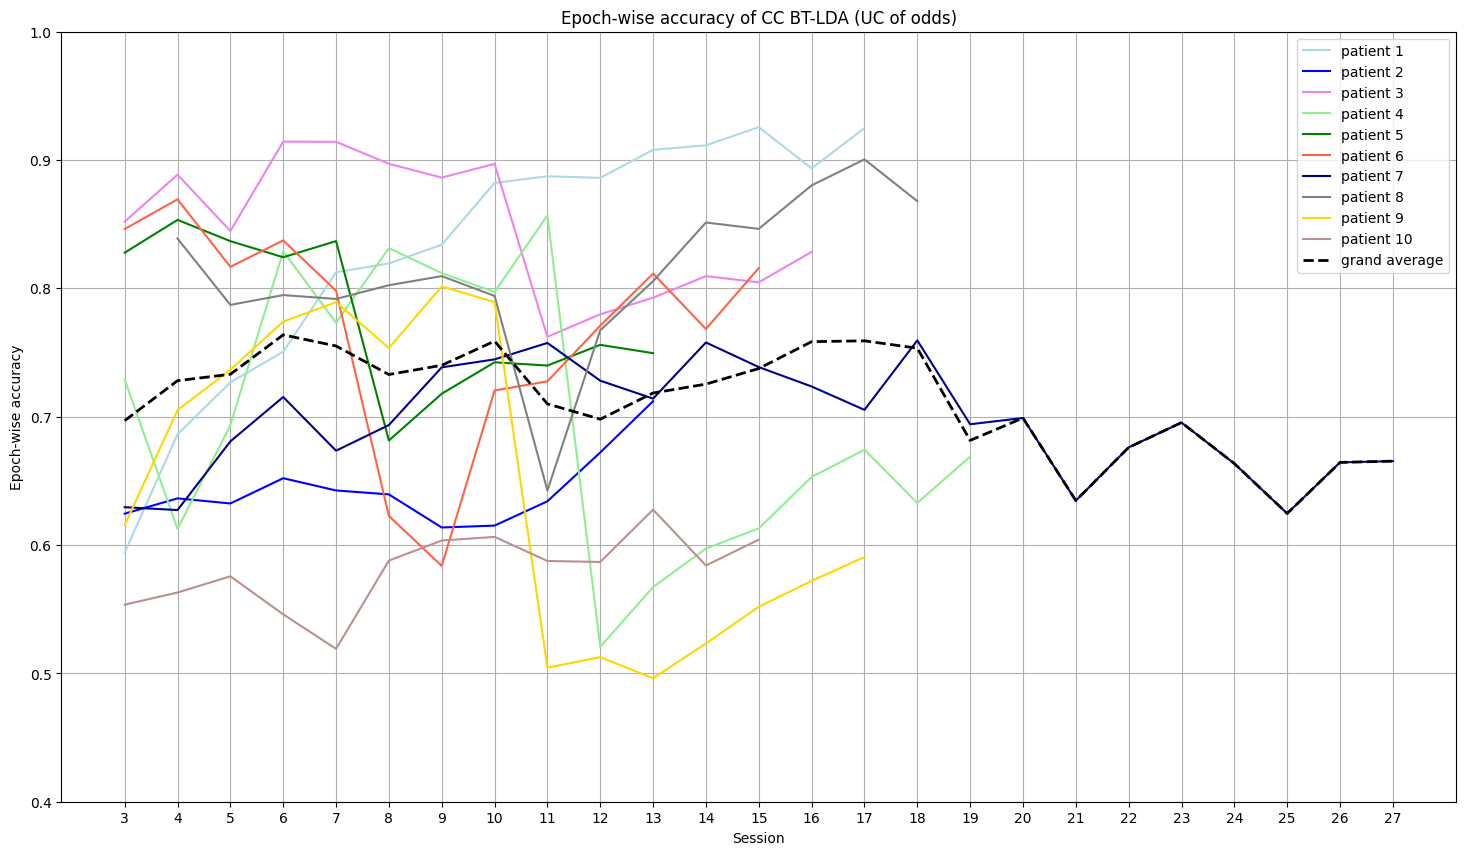

In [21]:
plot_all_patients(ews_all_cc_v2, grand_avg=ews_avg_cc_v2, title="Epoch-wise accuracy of CC BT-LDA (UC of odds)", ylabel="Epoch-wise accuracy")

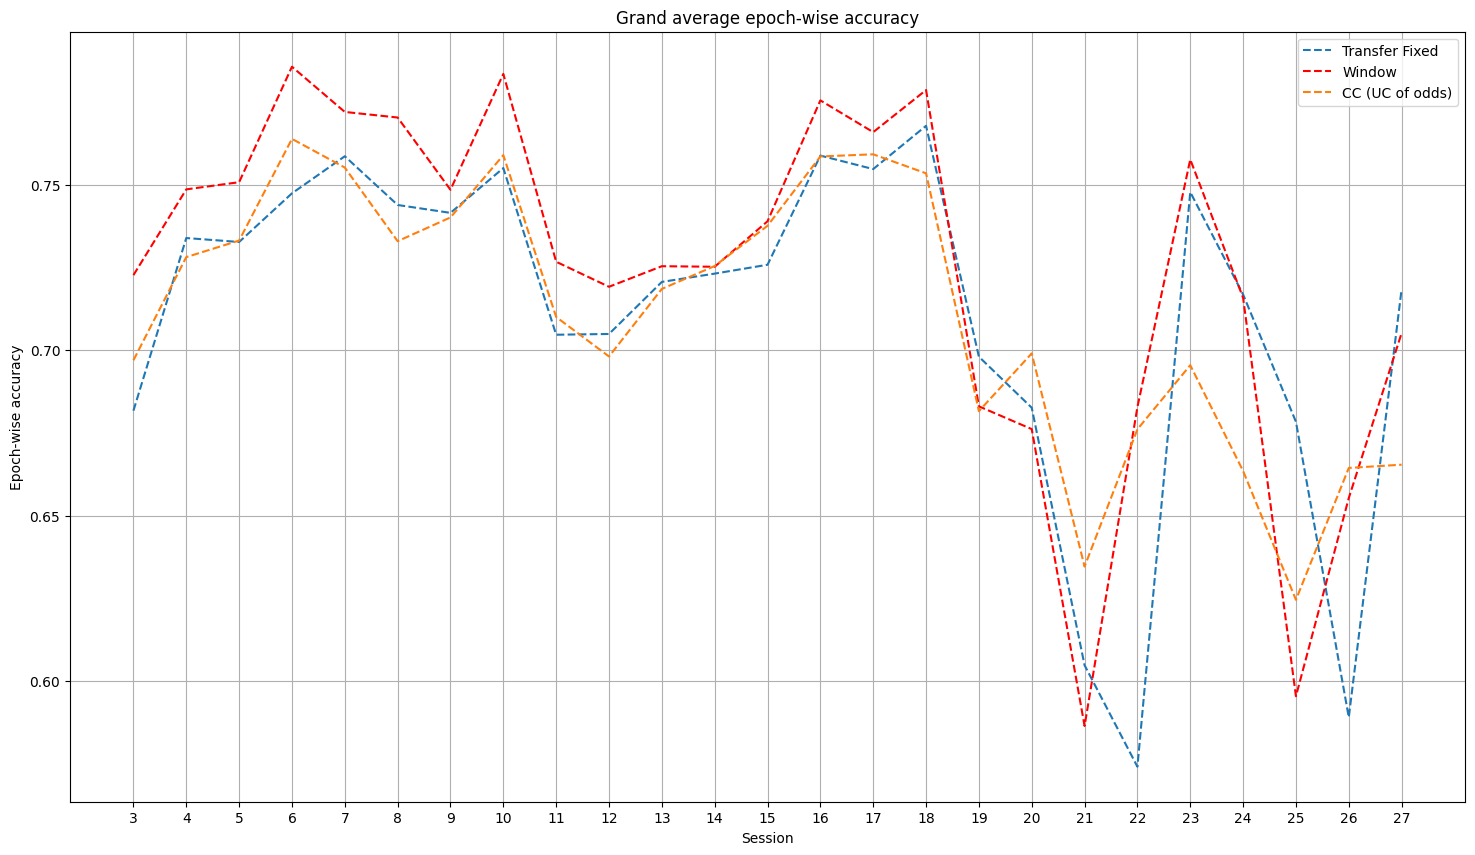

In [30]:
# plt.figure(figsize=(18,10))
# plt.plot(ews_avg_static, label="Static Fixed", linestyle='dashed')
# plt.plot(ews_avg_transfer, label="Transfer Fixed", linestyle='dashed')
# plt.ylabel("Epoch-wise accuracy")
# plt.xlabel('Session')
# plt.ylim(0.1,1)
# plt.xticks(np.arange(0,25), np.arange(3,28))    
# plt.legend()    
# plt.title("Grand average epoch-wise accuracy")   
# plt.grid() 
# plt.show()

plt.figure(figsize=(18,10))
plt.plot(ews_avg_transfer_v2, label="Transfer Fixed", linestyle='dashed')
plt.plot(ews_avg_window_v4, label="Window", linestyle='dashed', color="red")
#plt.plot(ews_avg_cc_v1, label="CC (UC of p9)", linestyle='dashed')
plt.plot(ews_avg_cc_v2, label="CC (UC of odds)", linestyle='dashed')

plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Session')
#plt.ylim(0.1,1)
plt.xticks(np.arange(0,25), np.arange(3,28))    
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

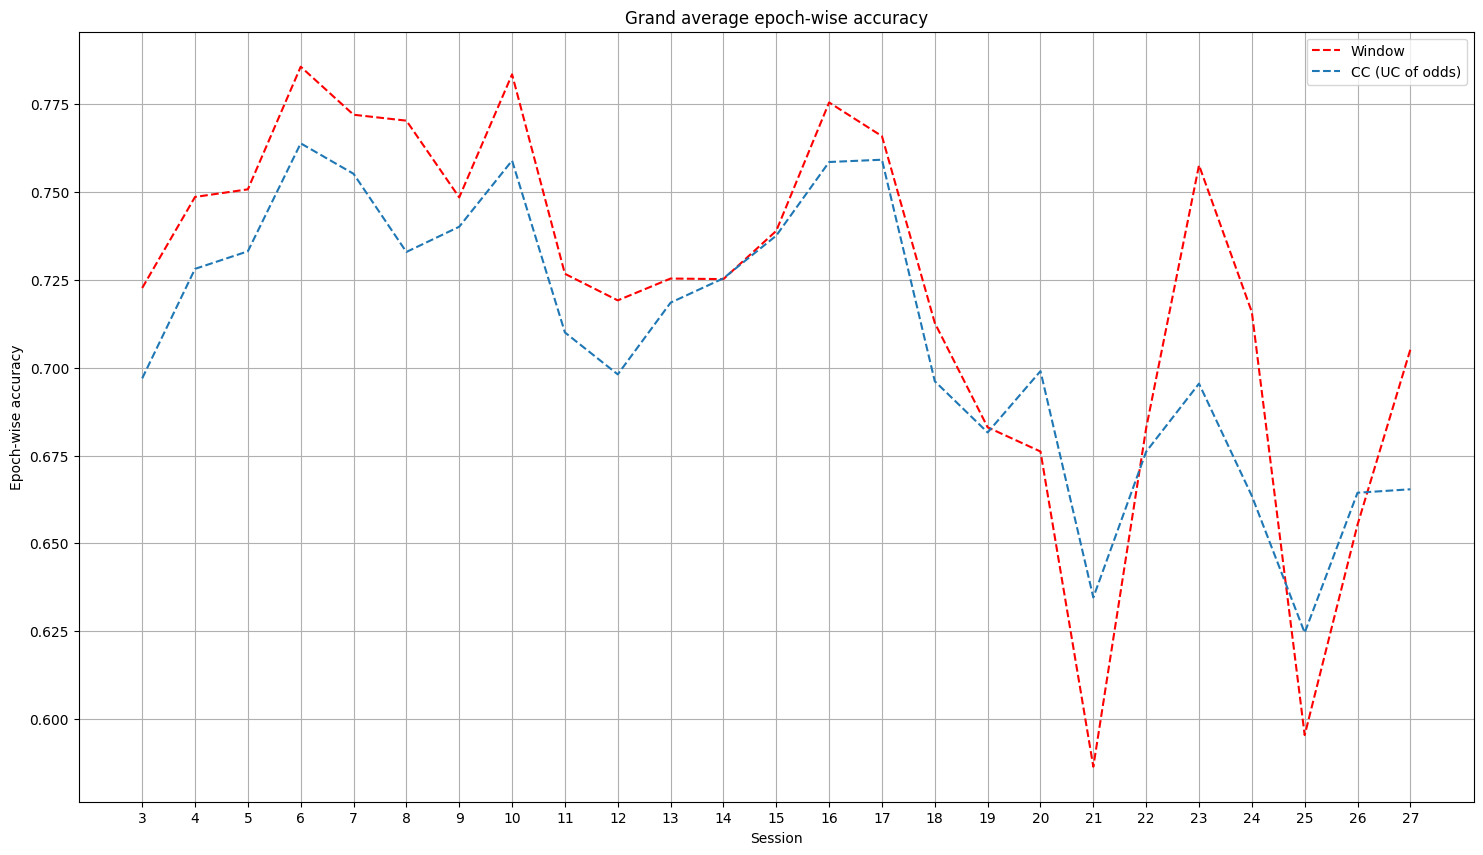

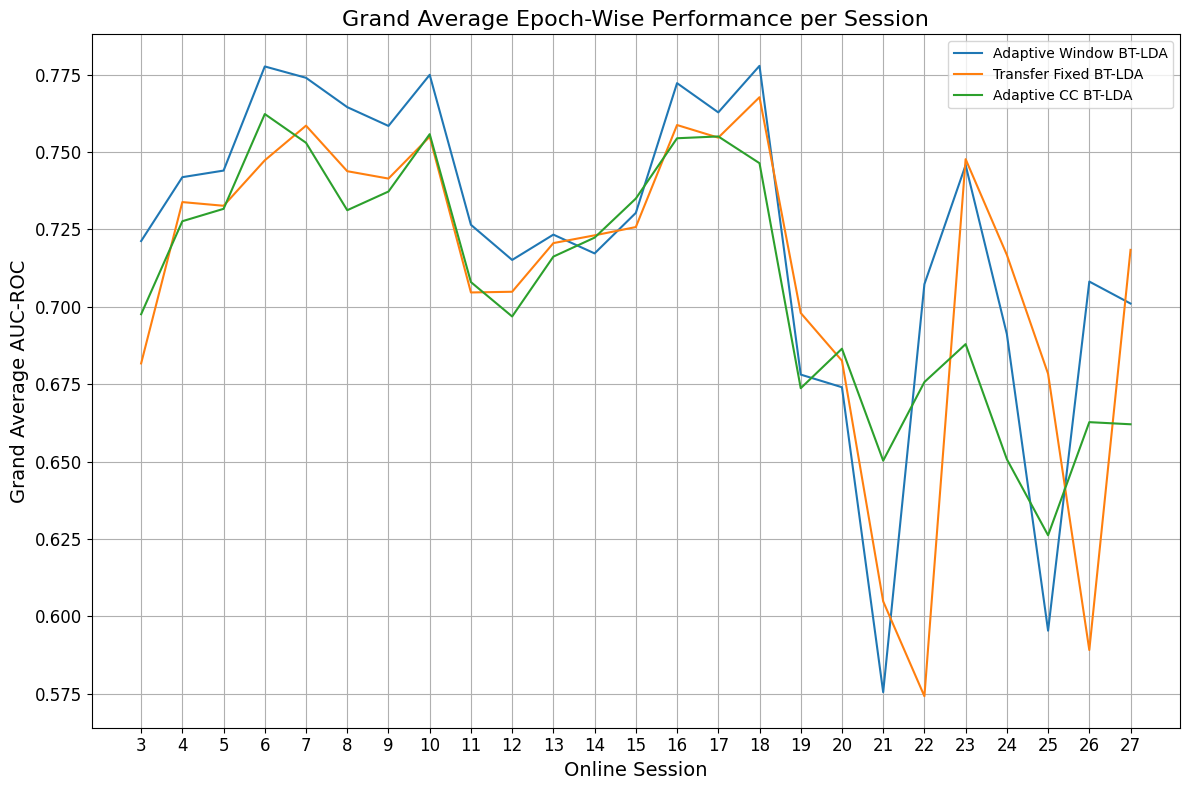

In [126]:
plt.figure(figsize=(18,10))
#plt.plot(ews_avg_transfer, label="Transfer Fixed", linestyle='dashed')
plt.plot(ews_avg_window_v4, label="Window", linestyle='dashed', color="red")
#plt.plot(ews_avg_cc_v1, label="CC (UC of p9)", linestyle='dashed')
plt.plot(ews_avg_cc_v2, label="CC (UC of odds)", linestyle='dashed')

plt.ylabel("Epoch-wise accuracy")
plt.xlabel('Session')
#plt.ylim(0.1,1)
plt.xticks(np.arange(0,25), np.arange(3,28))    
plt.legend()    
plt.title("Grand average epoch-wise accuracy")   
plt.grid() 
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

# Load data
# Group by session and compute the mean EWS per session
df = pd.read_csv('window5data.csv')
avg_ews_window = df.groupby('session')['ews'].mean().reset_index()
avg_tws_window = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv('transferdata.csv')
avg_ews_transfer = df.groupby('session')['ews'].mean().reset_index()
avg_tws_transfer = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv('ccdata.csv')
avg_ews_cc = df.groupby('session')['ews'].mean().reset_index()
avg_tws_cc = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv('aphasia_sldadata.csv')
avg_ews_slda = df.groupby('session')['ews'].mean().reset_index()
avg_tws_slda = df.groupby('session')['tws'].mean().reset_index()

df = pd.read_csv('staticdata.csv')
avg_ews_static = df.groupby('session')['ews'].mean().reset_index()

avg_tws_static = df.groupby('session')['tws'].mean().reset_index()


# Plotting
plt.figure(figsize=(12, 8))
plt.plot(avg_ews_window['session'], avg_ews_window['ews'], label='Adaptive Window BT-LDA')
plt.plot(avg_ews_transfer['session'], avg_ews_transfer['ews'], label='Transfer Fixed BT-LDA')
plt.plot(avg_ews_cc['session'], avg_ews_cc['ews'], label='Adaptive CC BT-LDA')
#plt.plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA')

plt.xlabel('Online Session', fontsize=14)           # bigger fontsize
plt.ylabel('Grand Average AUC-ROC', fontsize=14)
plt.title('Grand Average Epoch-Wise Performance per Session', fontsize=16)
plt.grid(True)
plt.xticks(avg_ews_transfer['session'], fontsize=12)
plt.yticks(fontsize=12)

plt.legend()
plt.tight_layout()
plt.show()


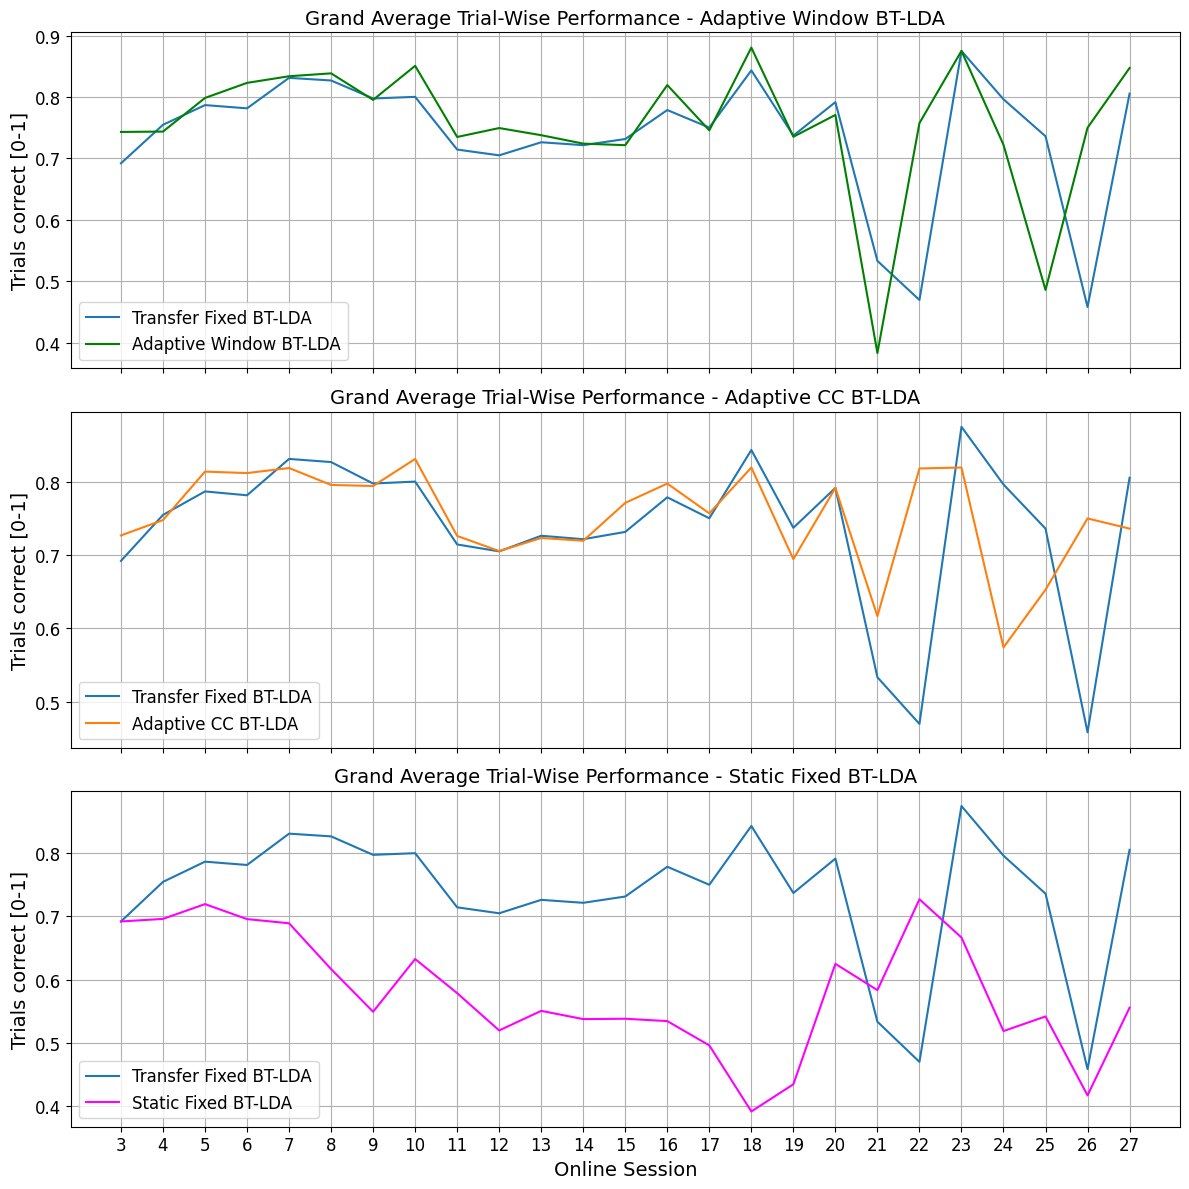

In [132]:
# First subplot
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axs[0].plot(avg_tws_transfer['session'], avg_tws_transfer['tws'], label='Transfer Fixed BT-LDA')
axs[0].plot(avg_tws_window['session'], avg_tws_window['tws'], label='Adaptive Window BT-LDA', color="green")
axs[0].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[0].set_title('Grand Average Trial-Wise Performance - Adaptive Window BT-LDA', fontsize=14)
axs[0].grid(True)
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)

# Second subplot
axs[1].plot(avg_tws_transfer['session'], avg_tws_transfer['tws'], label='Transfer Fixed BT-LDA')
axs[1].plot(avg_tws_cc['session'], avg_tws_cc['tws'], label='Adaptive CC BT-LDA')
axs[1].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[1].set_title('Grand Average Trial-Wise Performance - Adaptive CC BT-LDA', fontsize=14)
axs[1].grid(True)
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='y', labelsize=12)

# Third subplot
axs[2].plot(avg_tws_transfer['session'], avg_tws_transfer['tws'], label='Transfer Fixed BT-LDA')
axs[2].plot(avg_tws_static['session'], avg_tws_static['tws'], label='Static Fixed BT-LDA', color="magenta")
axs[2].set_xlabel('Online Session', fontsize=14)
axs[2].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[2].set_title('Grand Average Trial-Wise Performance - Static Fixed BT-LDA', fontsize=14)
axs[2].grid(True)
axs[2].legend(fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].set_xticks(avg_tws_transfer['session'])


plt.savefig("TWS_grandavgsessions_3plots.svg", bbox_inches="tight")
plt.savefig("TWS_grandavgsessions_3plots.pdf", bbox_inches="tight")
plt.savefig("TWS_grandavgsessions_3plots.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()

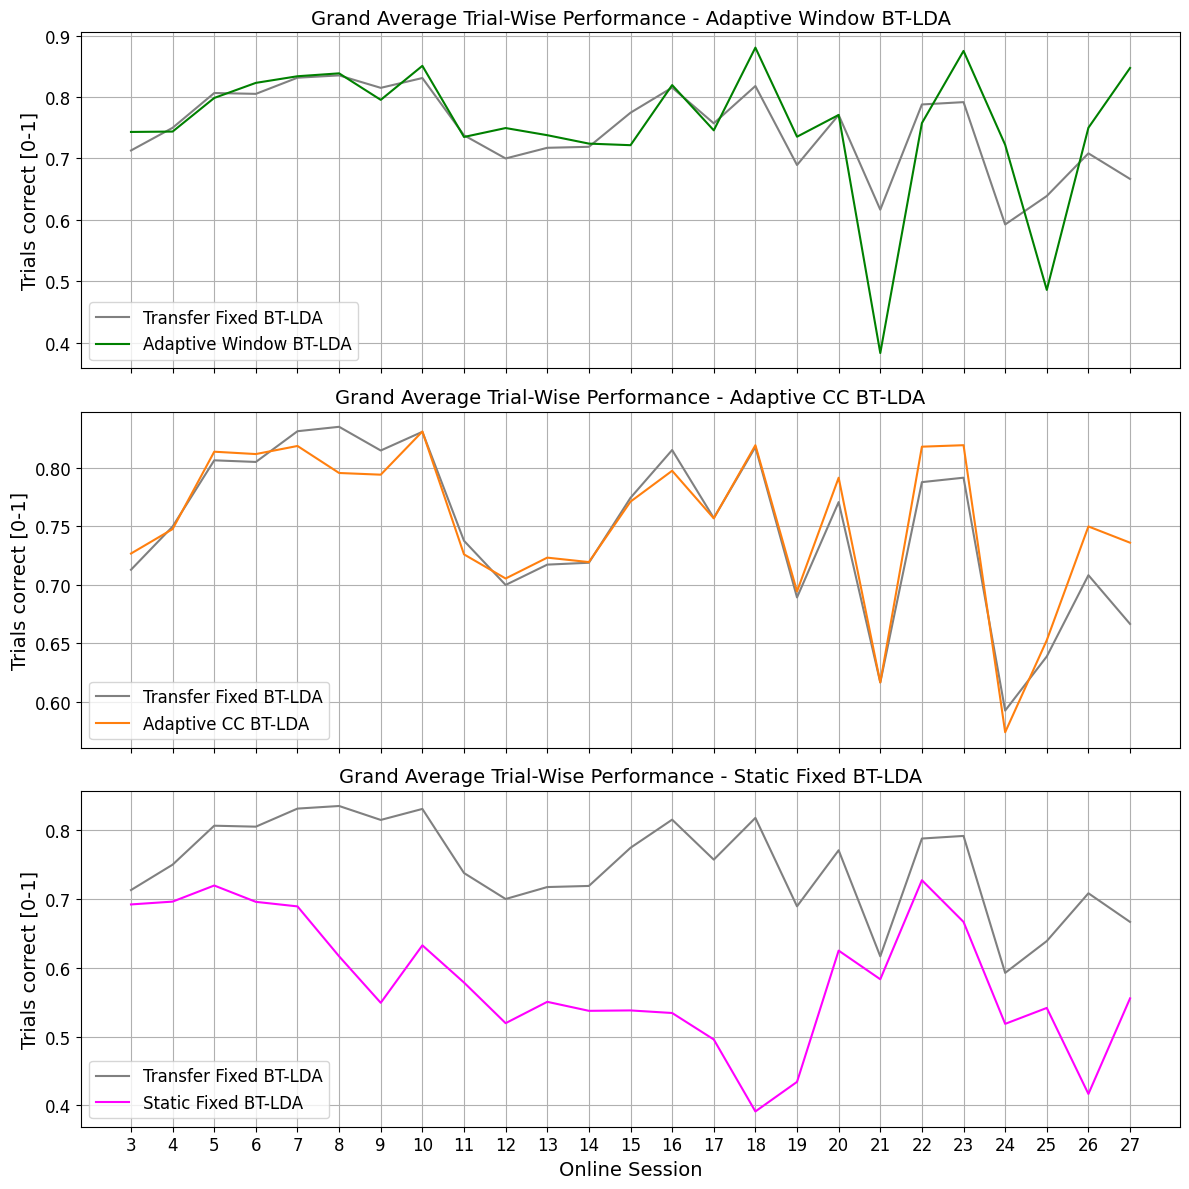

In [131]:
# First subplot
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axs[0].plot(avg_tws_slda['session'], avg_tws_slda['tws'], label='Transfer Fixed BT-LDA', color="grey")
axs[0].plot(avg_tws_window['session'], avg_tws_window['tws'], label='Adaptive Window BT-LDA', color="green")
axs[0].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[0].set_title('Grand Average Trial-Wise Performance - Adaptive Window BT-LDA', fontsize=14)
axs[0].grid(True)
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)

# Second subplot
axs[1].plot(avg_tws_slda['session'], avg_tws_slda['tws'], label='Transfer Fixed BT-LDA', color="grey")
axs[1].plot(avg_tws_cc['session'], avg_tws_cc['tws'], label='Adaptive CC BT-LDA',color="tab:orange")
axs[1].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[1].set_title('Grand Average Trial-Wise Performance - Adaptive CC BT-LDA', fontsize=14)
axs[1].grid(True)
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='y', labelsize=12)

# Third subplot
axs[2].plot(avg_tws_slda['session'], avg_tws_slda['tws'], label='Transfer Fixed BT-LDA',color="grey")
axs[2].plot(avg_tws_static['session'], avg_tws_static['tws'], label='Static Fixed BT-LDA', color="magenta")
axs[2].set_xlabel('Online Session', fontsize=14)
axs[2].set_ylabel('Trials correct [0-1]', fontsize=14)
axs[2].set_title('Grand Average Trial-Wise Performance - Static Fixed BT-LDA', fontsize=14)
axs[2].grid(True)
axs[2].legend(fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].set_xticks(avg_tws_slda['session'])


plt.savefig("TWS_SLDAgrandavgsessions_3plots.svg", bbox_inches="tight")
plt.savefig("TWS_SLDAgrandavgsessions_3plots.pdf", bbox_inches="tight")
plt.savefig("TWS_SLDAgrandavgsessions_3plots.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()

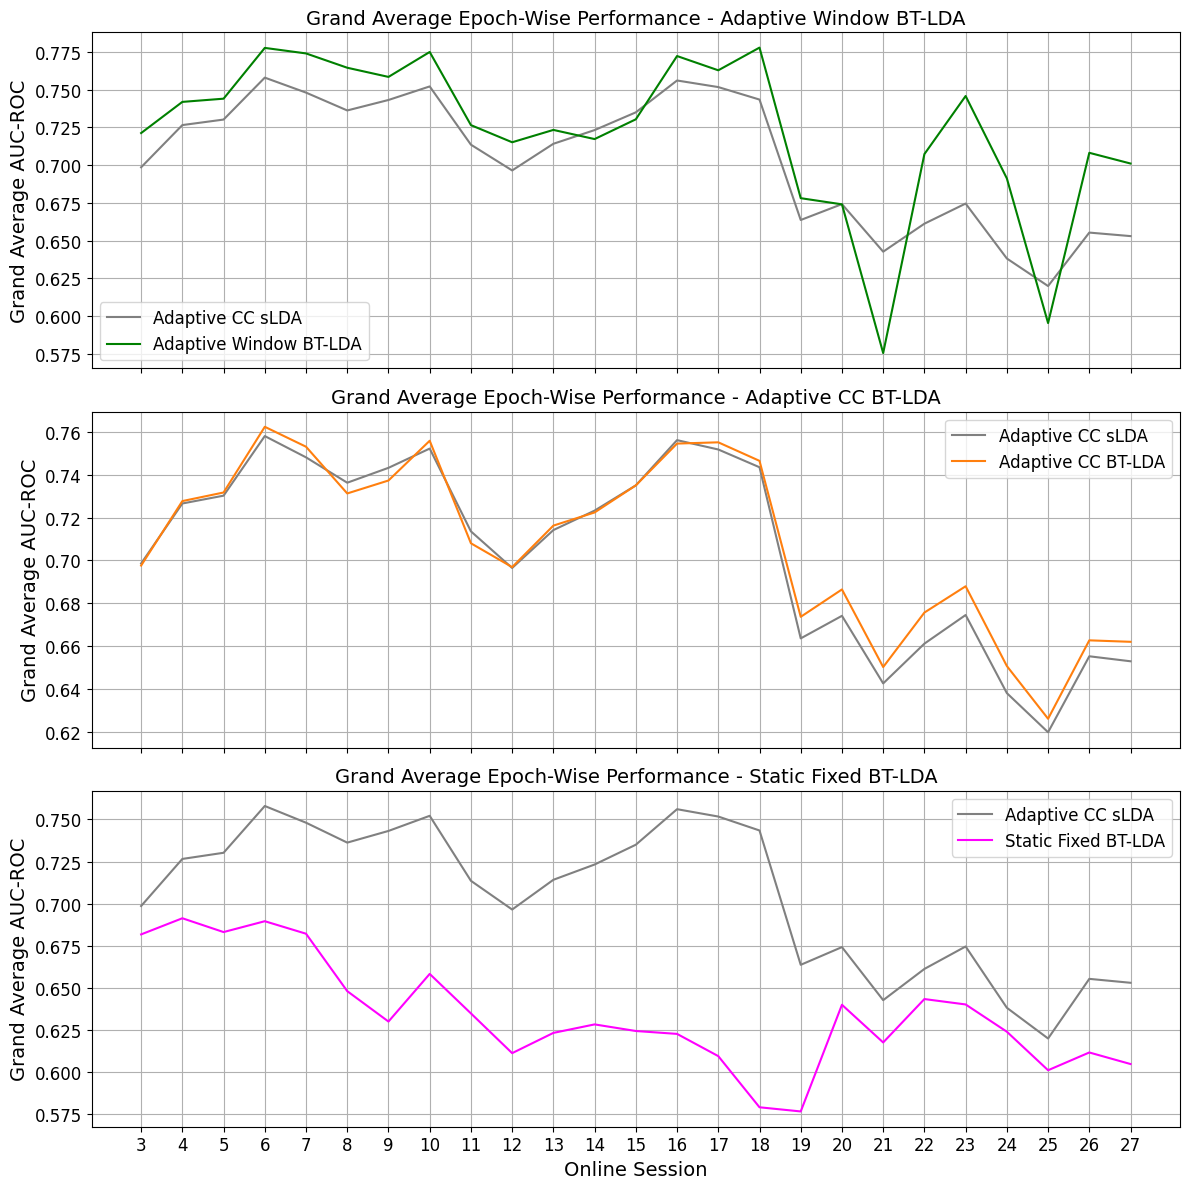

In [ ]:
# First subplot
fig, axs = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
axs[0].plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA', color="grey")
axs[0].plot(avg_ews_window['session'], avg_ews_window['ews'], label='Adaptive Window BT-LDA', color="green")
axs[0].set_ylabel('Grand Average AUC-ROC', fontsize=14)
axs[0].set_title('Grand Average Epoch-Wise Performance - Adaptive Window BT-LDA', fontsize=14)
axs[0].grid(True)
axs[0].legend(fontsize=12)
axs[0].tick_params(axis='y', labelsize=12)

# Second subplot
axs[1].plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA',color="grey")
axs[1].plot(avg_ews_cc['session'], avg_ews_cc['ews'], label='Adaptive CC BT-LDA', color="tab:orange")
axs[1].set_ylabel('Grand Average AUC-ROC', fontsize=14)
axs[1].set_title('Grand Average Epoch-Wise Performance - Adaptive CC BT-LDA', fontsize=14)
axs[1].grid(True)
axs[1].legend(fontsize=12)
axs[1].tick_params(axis='y', labelsize=12)

# Third subplot
axs[2].plot(avg_ews_slda['session'], avg_ews_slda['ews'], label='Adaptive CC sLDA',color="grey")
axs[2].plot(avg_ews_static['session'], avg_ews_static['ews'], label='Static Fixed BT-LDA', color="magenta")
axs[2].set_xlabel('Online Session', fontsize=14)
axs[2].set_ylabel('Grand Average AUC-ROC', fontsize=14)
axs[2].set_title('Grand Average Epoch-Wise Performance - Static Fixed BT-LDA', fontsize=14)
axs[2].grid(True)
axs[2].legend(fontsize=12)
axs[2].tick_params(axis='x', labelsize=12)
axs[2].tick_params(axis='y', labelsize=12)
axs[2].set_xticks(avg_ews_transfer['session'])


# plt.savefig("slda_grandavgsessions_3plots.svg", bbox_inches="tight")
# plt.savefig("slda_grandavgsessions_3plots.pdf", bbox_inches="tight")
# plt.savefig("slda_grandavgsessions_3plots.png", dpi=600, bbox_inches="tight")

plt.tight_layout()
plt.show()

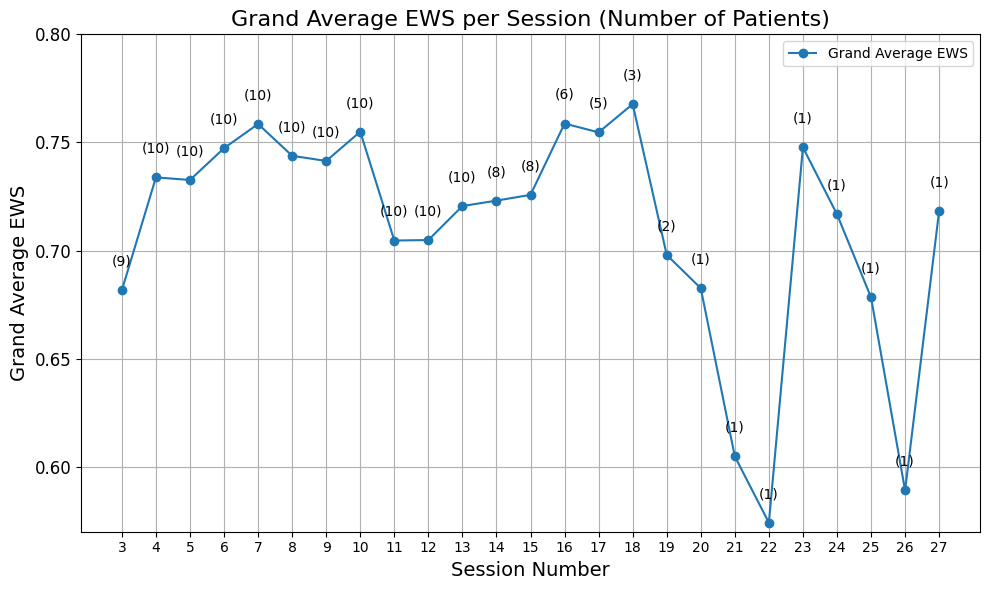

In [110]:
# Calculate number of patients per session
df = pd.read_csv('transferdata.csv')
avg_ews_transfer = df.groupby('session')['ews'].mean().reset_index()

counts = df.groupby('session')['patient'].nunique().reset_index()
counts.columns = ['session', 'n_patients']

# Merge with average EWS
avg_ews_transfer = df.groupby('session')['ews'].mean().reset_index()
avg_ews = avg_ews_transfer.merge(counts, on='session')

# Plot
plt.figure(figsize=(10, 6))
plt.plot(avg_ews['session'], avg_ews['ews'], marker='o', label='Grand Average EWS')

for i, row in avg_ews.iterrows():
    plt.text(row['session'], row['ews'] + 0.01, f"({int(row['n_patients'])})", 
             ha='center', va='bottom', fontsize=10)

plt.xlabel('Session Number', fontsize=14)
plt.ylabel('Grand Average EWS', fontsize=14)
plt.title('Grand Average EWS per Session (Number of Patients)', fontsize=16)
plt.grid(True)
plt.xticks(avg_ews['session'])
plt.yticks(fontsize=12)
plt.ylim(0.57,0.8)
plt.legend()
plt.tight_layout()


plt.savefig("patientnr_grandavgsessions.svg", bbox_inches="tight")
plt.savefig("patientnr_grandavgsessions.pdf", bbox_inches="tight")
plt.savefig("patientnr_grandavgsessions.png", dpi=600, bbox_inches="tight")

plt.show()


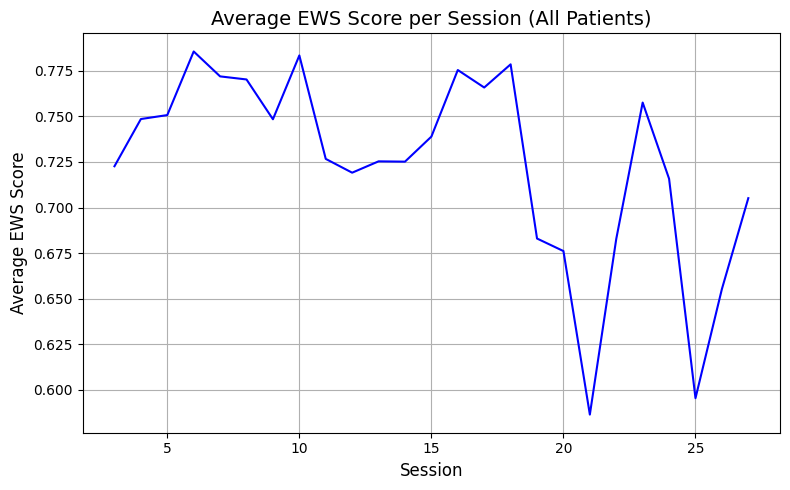

In [ ]:
# Read the CSV file
df = pd.read_csv("window4data.csv") 

# Group by session and compute the mean EWS score
avg_ews_per_session = df.groupby('session')['ews'].mean()

# Plot
plt.figure(figsize=(8, 5))
plt.plot(avg_ews_per_session.index, avg_ews_per_session.values, color='blue')
plt.xlabel("Session", fontsize=12)
plt.ylabel("Average EWS Score", fontsize=12)
plt.title("Average EWS Score per Session (All Patients)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

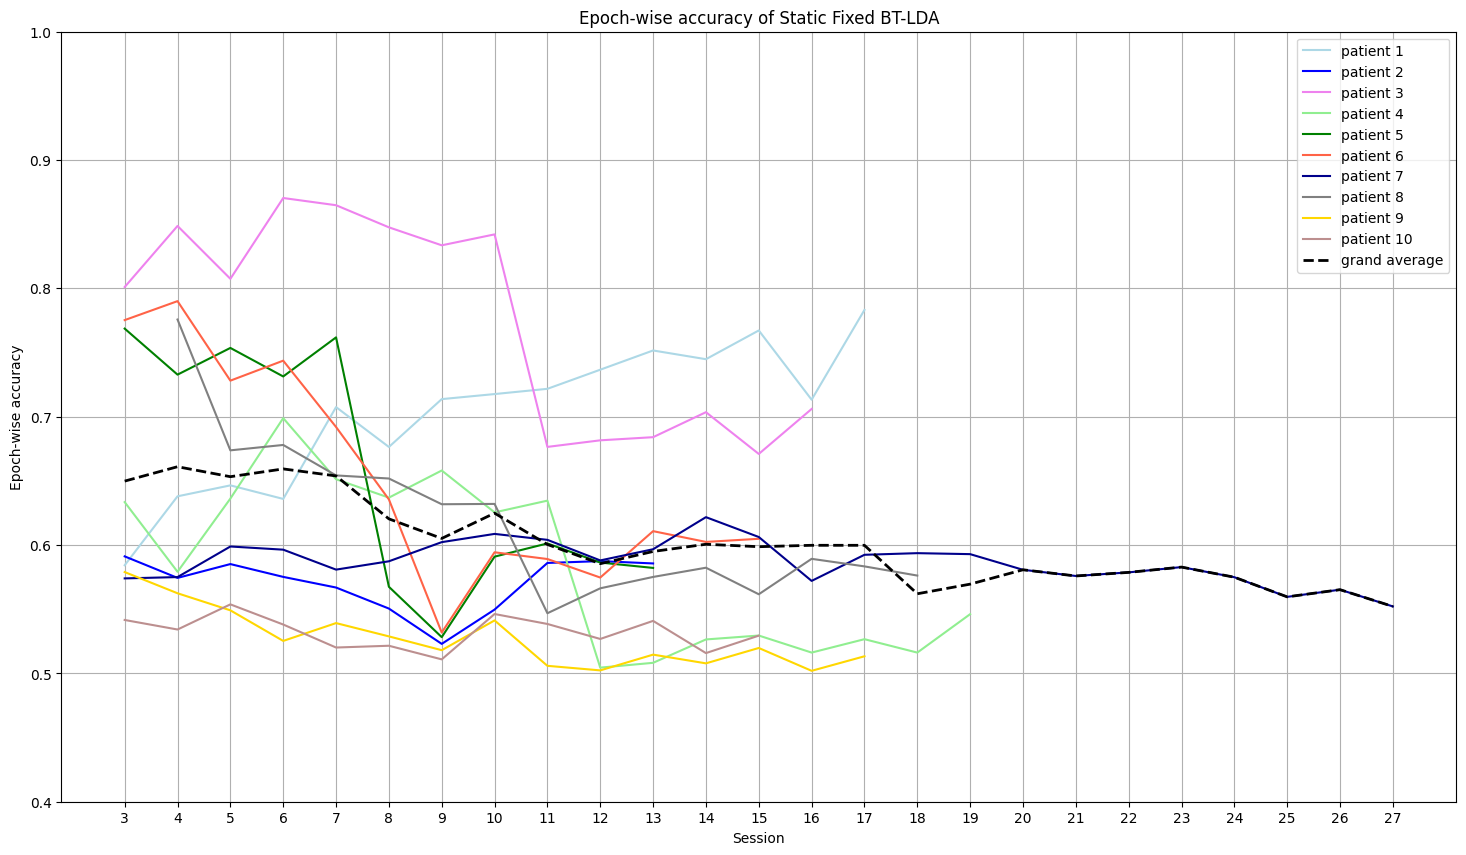

In [5]:

plot_all_patients(ews_all_static, grand_avg=ews_avg_static, title="Epoch-wise accuracy of Static Fixed BT-LDA", ylabel="Epoch-wise accuracy")